<div style="background: linear-gradient(135deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%); padding: 40px; border-radius: 12px; font-family: 'Segoe UI', Arial, sans-serif; color: white; margin-bottom: 20px;">
  <h1 style="font-size: 2.2em; margin: 0 0 8px 0; font-weight: 700; letter-spacing: 1px;">
    Práctica de Deep Learning
  </h1>
  <h2 style="font-size: 1.4em; margin: 0 0 24px 0; font-weight: 300; color: #a8d8ea;">
    Parte II — Predicción de Series Temporales con Transformers
  </h2>
  <table style="border-collapse: collapse; width: 100%; font-size: 0.95em;">
    <tr>
      <td style="padding: 6px 16px 6px 0; color: #a8d8ea; font-weight: 600;">Asignatura</td>
      <td style="padding: 6px 0;">Aprendizaje Automático II</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px 6px 0; color: #a8d8ea; font-weight: 600;">Tareas</td>
      <td style="padding: 6px 0;">Seno sintético · Acciones AAPL (yfinance)</td>
    </tr>
    <tr>
      <td style="padding: 6px 16px 6px 0; color: #a8d8ea; font-weight: 600;">Framework</td>
      <td style="padding: 6px 0;">PyTorch — nn.TransformerEncoder</td>
    </tr>
  </table>
  <hr style="border: none; border-top: 1px solid #a8d8ea44; margin: 20px 0 10px 0;">
  <p style="margin: 0; font-size: 0.8em; color: #a8d8ea88;">Universidad Politécnica de Madrid · Aprendizaje Automático II</p>
</div>

## Descripción general

Los **Transformers** fueron diseñados originalmente para procesar secuencias de texto (NLP), pero su mecanismo de **atención multi-cabeza** los hace igualmente poderosos para series temporales: en lugar de palabras, la secuencia son valores numéricos ordenados en el tiempo.

### Ventaja frente a RNNs/LSTMs

| Aspecto | RNN / LSTM | Transformer |
|---|---|---|
| Dependencias largas | Difícil (gradiente que desvanece) | Directas vía atención |
| Paralelización | Secuencial | Total (entrenamiento rápido) |
| Interpretabilidad | Opaca | Pesos de atención visibles |

### Tareas de esta práctica

| # | Tarea | Datos | Predicción |
|---|---|---|---|
| 1 | Función seno sintética | 1 000 puntos generados | 200 valores futuros |
| 2 | Precio diario AAPL | Yahoo Finance 2020–2026 | 50 días futuros |

### Arquitectura general

```
Entrada  [batch, seq_len, 1]
   │
   ▼
Linear (input_projection)   ← proyecta 1 → d_model
   │
   ▼
TransformerEncoder           ← N capas de self-attention + FFN
   │
   ▼
Último token  [:, -1, :]    ← estado del instante más reciente
   │
   ▼
Linear (output_layer)        ← predice el siguiente valor escalar
   │
   ▼
Salida  [batch, 1]
```

> **Nota:** Se usa solo el **Encoder** (sin Decoder). El modelo aprende a comprimir toda la ventana de contexto en el último token y a partir de él predecir el siguiente paso.

## 1. Predicción de Función Seno

La función seno es el banco de pruebas ideal para un modelo de series temporales: es **periódica, suave y determinista**. Si el Transformer no consigue aprender el patrón del seno, no tiene sentido pasarle datos reales de bolsa.

### 1.1 Generación de datos y ventanas deslizantes

Se generan 1 000 puntos de `sin(t)` con `t ∈ [0, 100]`. Luego se construyen pares `(X, y)` mediante una **ventana deslizante** de tamaño `seq_length = 50`:

```
t:  [0,  1,  2, ... 49]  → predice t[50]
t:  [1,  2,  3, ... 50]  → predice t[51]
    ...
```

Esto transforma la serie en un problema de regresión supervisado estándar. El resultado son tensores de forma `X: [950, 50, 1]` e `y: [950, 1]`.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Crear la onda seno
t = np.linspace(0, 100, 1000) # 1000 puntos de 0 a 100
data = np.sin(t).reshape(-1, 1)

# 2. Función para crear ventanas (Secuencias)
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 50 
X, y = create_sequences(data, seq_length)

# Convertir a Tensores
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
X = torch.from_numpy(X).float().to(device)
y = torch.from_numpy(y).float().to(device)

cuda


### 1.2 Arquitectura — `SequenceTransformer`

Transformer ligero optimizado para la señal seno. Hiperparámetros:

| Parámetro | Valor | Descripción |
|---|---|---|
| `d_model` | 32 | Dimensión del espacio de embeddings |
| `nhead` | 4 | Cabezas de atención paralelas (32 / 4 = 8 dim/cabeza) |
| `num_layers` | 2 | Capas apiladas del Encoder |
| `seq_length` | 50 | Contexto de entrada (50 pasos anteriores) |

**Flujo interno:**

1. `input_projection` — Lineal `1 → 32`: cada valor escalar pasa a un vector de 32 dimensiones que el Transformer puede procesar.
2. `TransformerEncoder` — 2 capas de `TransformerEncoderLayer`. Cada capa aplica **self-attention** (los 50 tokens se "miran" entre sí) seguida de una red feed-forward.
3. `x[:, -1, :]` — Se extrae solo el último token de la secuencia, que acumula información de todo el contexto gracias a la atención.
4. `output_layer` — Lineal `32 → 1`: produce el valor predicho del siguiente instante.

In [2]:
class SequenceTransformer(nn.Module):
    def __init__(self, d_model=32, nhead=4):
        super(SequenceTransformer, self).__init__()
        # Proyección de entrada: de 1 feature a d_model dimensiones
        self.input_projection = nn.Linear(1, d_model)
        # Capa del Encoder Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        # Capa de salida: de d_model a 1 predicción
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):  # x: [batch, seq_len, 1]
        x = self.input_projection(x)  # [batch, seq_len, d_model]
        x = self.transformer(x)       # [batch, seq_len, d_model]
        x = x[:, -1, :]              # Último paso temporal [batch, d_model]
        x = self.output_layer(x)      # [batch, 1]
        return x

model = SequenceTransformer().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

model

SequenceTransformer(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
)

### 1.3 Entrenamiento

Se entrena con **batch completo** (todos los 950 ejemplos a la vez) durante 100 épocas. La función de pérdida es el **Error Cuadrático Medio (MSE)** entre el valor predicho y el real:

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2$$

El optimizador **Adam** con `lr = 0.001` ajusta los pesos de forma adaptativa. Al tratarse de un seno, la pérdida debería descender por debajo de `1e-4` rápidamente.

In [3]:
epochs = 100

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X)          # Forward pass
    loss = criterion(output, y)
    loss.backward()            # Backpropagation
    optimizer.step()           # Actualizar pesos

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}  |  Loss: {loss.item():.6f}")

Epoch 10/100  |  Loss: 0.192607
Epoch 20/100  |  Loss: 0.026765
Epoch 30/100  |  Loss: 0.018320
Epoch 40/100  |  Loss: 0.017481
Epoch 50/100  |  Loss: 0.014053
Epoch 60/100  |  Loss: 0.012101
Epoch 70/100  |  Loss: 0.010250
Epoch 80/100  |  Loss: 0.008648
Epoch 90/100  |  Loss: 0.007860
Epoch 100/100  |  Loss: 0.006890


### 1.4 Predicción Autorregresiva

Una vez entrenado, el modelo genera los valores futuros de forma **autorregresiva**: cada predicción se convierte en la entrada del siguiente paso. La ventana se desplaza hacia adelante en cada iteración:

```
Ventana inicial:  [t₋₄₉, t₋₄₈, ..., t₀]  → predice  t₁
Ventana siguiente: [t₋₄₈, t₋₄₇, ..., t₁]  → predice  t₂
...
```

> **Importante:** El error se acumula con cada paso. Para el seno (función periódica y determinista) esto funciona bien; para datos reales la incertidumbre crece con el horizonte de predicción.

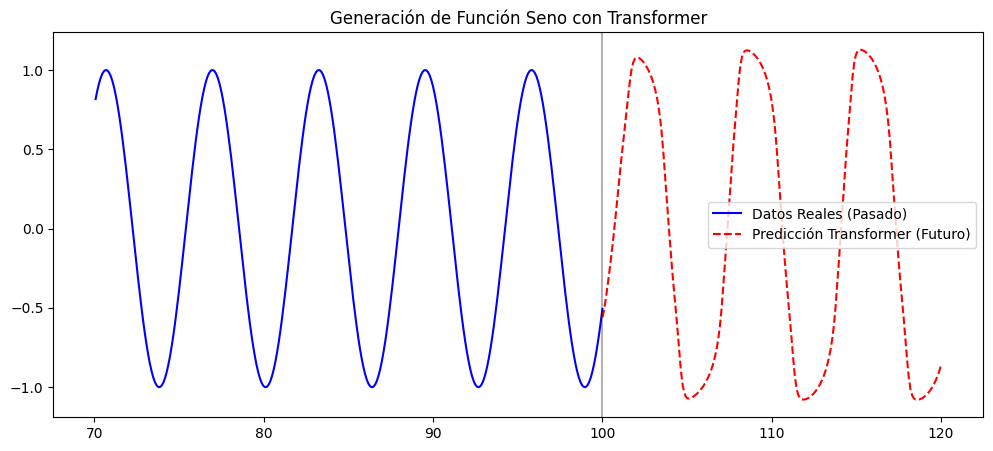

In [4]:
model.eval()
future_points = 200
predictions = []

# Tomamos la última ventana de los datos reales para empezar
last_sequence = X[-1].unsqueeze(0) 

for _ in range(future_points):
    with torch.no_grad():
        pred = model(last_sequence) # Predice el siguiente punto
        predictions.append(pred.item())
        
        # Actualizamos la ventana: desplazamos y añadimos la predicción
        new_row = pred.unsqueeze(1) 
        last_sequence = torch.cat((last_sequence[:, 1:, :], new_row), dim=1)

# Pintar resultados
plt.figure(figsize=(12,5))
plt.plot(t[-300:], data[-300:], label="Datos Reales (Pasado)", color="blue")
plt.plot(np.linspace(t[-1], t[-1]+20, future_points), predictions, label="Predicción Transformer (Futuro)", linestyle="--", color="red")
plt.axvline(x=t[-1], color='black', alpha=0.3)
plt.legend()
plt.title("Generación de Función Seno con Transformer")
plt.show()

### 1.5 Métricas de Evaluación

Se calculan dos conjuntos de métricas:

1. **Predicción un paso** — el modelo predice `t+1` dado `[t-49…t]` sobre todo el conjunto de entrenamiento. Mide la calidad del ajuste interno.
2. **Predicción autorregresiva** — las 200 predicciones futuras se comparan con el seno real calculado analíticamente. Mide cuánto se degrada el error al propagar predicciones.

| Métrica | Fórmula |
|---|---|
| MSE | $\frac{1}{N}\sum(\hat{y}-y)^2$ |
| RMSE | $\sqrt{\text{MSE}}$ — mismas unidades que la señal |
| MAE | $\frac{1}{N}\sum|\hat{y}-y|$ — robusto a outliers |
| MAPE | $\frac{100}{N}\sum\left|\frac{\hat{y}-y}{y}\right|$ — error relativo (%) |
| R² | $1 - \frac{\sum(\hat{y}-y)^2}{\sum(\bar{y}-y)^2}$ — varianza explicada (1 = perfecto) |

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Métricas un paso (sobre todo el conjunto de entrenamiento) ──────────────
model.eval()
with torch.no_grad():
    train_preds = model(X).cpu().numpy()
y_np = y.cpu().numpy()

mse  = mean_squared_error(y_np, train_preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_np, train_preds)
mape = np.mean(np.abs((y_np - train_preds) / (np.abs(y_np) + 1e-8))) * 100
r2   = r2_score(y_np, train_preds)

print("=" * 50)
print("  Métricas — Seno (predicción un paso, N=950)")
print("=" * 50)
print(f"  MSE  : {mse:.6f}")
print(f"  RMSE : {rmse:.6f}")
print(f"  MAE  : {mae:.6f}")
print(f"  MAPE : {mape:.4f} %")
print(f"  R²   : {r2:.6f}")

# ── Métricas autorregresivas (200 pasos futuros vs seno real) ───────────────
t_future   = np.linspace(t[-1], t[-1] + 20, future_points)
sin_future = np.sin(t_future)
preds_arr  = np.array(predictions)

mse_ar  = mean_squared_error(sin_future, preds_arr)
rmse_ar = np.sqrt(mse_ar)
mae_ar  = mean_absolute_error(sin_future, preds_arr)
r2_ar   = r2_score(sin_future, preds_arr)

print()
print("=" * 50)
print("  Métricas — Seno (autorregresivo, 200 pasos futuros)")
print("=" * 50)
print(f"  RMSE : {rmse_ar:.6f}")
print(f"  MAE  : {mae_ar:.6f}")
print(f"  R²   : {r2_ar:.6f}")
print()
print("  > Un R² cercano a 1 indica que el modelo captura")
print("    correctamente la periodicidad de la función seno.")

  Métricas — Seno (predicción un paso, N=950)
  MSE  : 0.001204
  RMSE : 0.034694
  MAE  : 0.029542
  MAPE : 32.6236 %
  R²   : 0.997597

  Métricas — Seno (autorregresivo, 200 pasos futuros)
  RMSE : 0.588395
  MAE  : 0.457139
  R²   : 0.273332

  > Un R² cercano a 1 indica que el modelo captura
    correctamente la periodicidad de la función seno.


---

## 2. Predicción de Acciones de Apple (AAPL)

Se aplica un Transformer a datos reales de bolsa descargados con **yfinance**. Los precios bursátiles presentan desafíos ausentes en el seno:

- **No estacionariedades** — la media y varianza cambian con el tiempo
- **Ruido** e impredecibilidad por eventos externos
- **Escala creciente** → normalización imprescindible

### Mejoras respecto a la versión básica

La versión inicial producía predicciones planas (R² ≈ −7) porque el modelo no tenía noción de orden temporal y convergía a predecir la media del entrenamiento. Se introducen cuatro mejoras:

| Mejora | Problema que resuelve |
|---|---|
| **Positional Encoding sinusoidal** | El Transformer no sabe qué token es "antes" o "después" sin esta información |
| **Sin data leakage en el scaler** | Ajustar el `MinMaxScaler` con datos de test es trampa: el modelo no debería ver el futuro durante el preprocesado |
| **`ReduceLROnPlateau` scheduler** | Si el modelo deja de mejorar, reduce la tasa de aprendizaje automáticamente en lugar de quedarse estancado |
| **Gradient clipping** | Evita actualizaciones de pesos catastróficas cuando los gradientes se disparan |

### 2.1 Datos y preprocesamiento

| Parámetro | Valor |
|---|---|
| Ticker | `AAPL` |
| Periodo | 2020-01-01 — 2026-01-01 |
| Feature | Precio de cierre (`Close`) |
| Normalización | `MinMaxScaler` ajustado **solo** con train → `[0, 1]` |
| `seq_length` | 60 días (contexto de 3 meses) |
| Split | 80 % train · 20 % test (temporal) |

> **Por qué ajustar el scaler solo con train:** Si se ajusta con todos los datos, el `max` y `min` del scaler incluyen valores del test set. El modelo se normalizaría conociendo precios futuros — una fuga de información que inflaría artificialmente las métricas.

In [6]:
%pip install --upgrade yfinance

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Configuración de dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Note: you may need to restart the kernel to use updated packages.


In [7]:
# Descargar datos
df = yf.download('AAPL', start='2020-01-01', end='2026-01-01')
data = df['Close'].values.reshape(-1, 1)

seq_length = 60

# ── Split temporal ANTES de normalizar (evitar data leakage) ─────────────────
split_idx  = int(len(data) * 0.8)
train_raw  = data[:split_idx]
# Para test necesitamos seq_length días de solapamiento para construir las primeras ventanas
test_raw   = data[split_idx - seq_length:]

# Scaler ajustado SOLO con datos de entrenamiento
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
test_scaled  = scaler.transform(test_raw)

# Guardamos también el histórico completo escalado para visualización
data_scaled_full = scaler.transform(data)

# ── Ventanas deslizantes ──────────────────────────────────────────────────────
def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:i + seq_length])
        ys.append(data[i + seq_length])
    return np.array(xs), np.array(ys)

X_train_np, y_train_np = create_sequences(train_scaled, seq_length)
X_test_np,  y_test_np  = create_sequences(test_scaled,  seq_length)

# Última ventana real (para arrancar la predicción autorregresiva futura)
last_window        = scaler.transform(data[-seq_length:])
last_window_tensor = torch.from_numpy(last_window).float().unsqueeze(0).to(device)

# ── Convertir a tensores ──────────────────────────────────────────────────────
X_train = torch.from_numpy(X_train_np).float().to(device)
y_train = torch.from_numpy(y_train_np).float().to(device)
X_test  = torch.from_numpy(X_test_np).float().to(device)
y_test  = torch.from_numpy(y_test_np).float().to(device)

print(f"Total días      : {len(data)}")
print(f"Train           : {X_train.shape[0]} ventanas  (días 0 → {split_idx})")
print(f"Test            : {X_test.shape[0]}  ventanas  (días {split_idx} → {len(data)})")
print(f"Scaler rango    : [{scaler.data_min_[0]:.2f}, {scaler.data_max_[0]:.2f}] USD (solo train)")

[*********************100%***********************]  1 of 1 completed

Total días      : 1508
Train           : 1146 ventanas  (días 0 → 1206)
Test            : 302  ventanas  (días 1206 → 1508)
Scaler rango    : [54.21, 233.02] USD (solo train)


### 2.2 Arquitectura — `TimeSeriesTransformer` con Positional Encoding

#### ¿Por qué Positional Encoding?

El mecanismo de self-attention es **permutation-invariant**: si reordenamos los tokens de entrada, la salida es la misma (salvo en el orden). Para secuencias temporales esto es un problema grave — el modelo no sabría si el valor de ayer es anterior o posterior al de hoy.

El **Positional Encoding sinusoidal** (Vaswani et al., 2017) resuelve esto sumando a cada embedding un vector que depende únicamente de su posición:

$$PE_{(pos,\,2i)} = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right) \qquad PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Cada posición obtiene un vector único. Las frecuencias altas distinguen posiciones contiguas; las bajas capturan relaciones a larga distancia.

#### Hiperparámetros

| Parámetro | Valor | Justificación |
|---|---|---|
| `d_model` | 64 | Espacio de representación suficiente para capturar tendencias financieras |
| `nhead` | 4 | 4 cabezas × 16 dim/cabeza — varios "puntos de vista" sobre la secuencia |
| `num_layers` | 3 | Más profundidad para relaciones no lineales complejas |
| `dim_feedforward` | 256 | Red FFN 4× más ancha que `d_model` (convención estándar) |
| `dropout` | 0.1 | Regularización en attention + FFN |

#### Flujo completo

```
[batch, 60, 1]
   │
   ▼  Linear 1→64
[batch, 60, 64]
   │
   ▼  + PositionalEncoding
[batch, 60, 64]   ← cada token sabe su posición en la ventana
   │
   ▼  TransformerEncoder (3 capas)
[batch, 60, 64]
   │
   ▼  x[:, -1, :]   ← último token resume toda la secuencia
[batch, 64]
   │
   ▼  Linear 64→1
[batch, 1]         ← precio del día siguiente (normalizado)
```

In [8]:
import math

class PositionalEncoding(nn.Module):
    """
    Codificación posicional sinusoidal (Vaswani et al., 2017).

    Suma a cada embedding un vector único según su posición en la secuencia:
        PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Los pesos pe NO son entrenables (register_buffer): son fijos y deterministas.
    """
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]

    def forward(self, x):
        # x: [batch, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class TimeSeriesTransformer(nn.Module):
    """
    Transformer para predicción de series temporales financieras.

    Mejoras frente a la versión básica:
      - PositionalEncoding: el modelo conoce el orden temporal de cada token.
      - 3 capas de Encoder (vs 2): mayor capacidad de representación.
      - dim_feedforward=256: FFN interna 4× d_model (convención estándar).
      - weight_decay en el optimizador: regularización L2 adicional.
    """
    def __init__(self, input_size=1, d_model=64, nhead=4, num_layers=3,
                 dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoding     = PositionalEncoding(d_model, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):             # x: [batch, seq_len, input_size]
        x = self.input_projection(x)  # [batch, seq_len, d_model]
        x = self.pos_encoding(x)      # + codificación posicional sinusoidal
        x = self.transformer(x)       # [batch, seq_len, d_model]
        x = x[:, -1, :]              # último token [batch, d_model]
        return self.output_layer(x)   # [batch, 1]


model     = TimeSeriesTransformer().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)
print(f"\nParámetros entrenables: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

TimeSeriesTransformer(
  (input_projection): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)

Parámetros entrenables: 150,145


### 2.3 Entrenamiento con Scheduler y Gradient Clipping

Se entrena durante **200 épocas** con dos técnicas adicionales:

#### `ReduceLROnPlateau`
Reduce la tasa de aprendizaje en un factor `0.5` cuando la **Test Loss** no mejora durante 15 épocas consecutivas. Permite un descenso agresivo al inicio y ajuste fino al final sin necesidad de fijar una curva de LR manualmente.

```
LR inicial: 1e-3
Si no mejora 15 épocas → LR = LR × 0.5
LR mínima: 1e-6
```

#### Gradient Clipping (`max_norm=1.0`)
Rescala el gradiente si su norma supera 1.0. Impide actualizaciones catastróficas que sacarían el modelo del óptimo. Es especialmente útil con Transformers, que pueden tener gradientes grandes en las capas de atención.

$$\text{Si } \|\nabla\| > 1.0 \quad\Rightarrow\quad \nabla \leftarrow \frac{\nabla}{\|\nabla\|}$$

#### `weight_decay=1e-5` en Adam
Equivale a regularización L2: penaliza pesos grandes, reduciendo el sobreajuste junto con el dropout.

In [9]:
epochs    = 200
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=15, factor=0.5, min_lr=1e-6
)

best_test_loss = float('inf')

for epoch in range(epochs):
    # ── Forward + backward sobre datos de entrenamiento ──────────────────────
    model.train()
    optimizer.zero_grad()
    output = model(X_train)
    loss   = criterion(output, y_train)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
    optimizer.step()

    # ── Evaluación en test (sin gradientes) ───────────────────────────────────
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test), y_test).item()

    scheduler.step(test_loss)  # ajusta LR si el test loss se estanca

    if test_loss < best_test_loss:
        best_test_loss = test_loss

    if (epoch + 1) % 25 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d}/{epochs} | Train: {loss.item():.6f} | Test: {test_loss:.6f} | LR: {lr_now:.2e}")

print(f"\nMejor Test Loss alcanzado: {best_test_loss:.6f}")

Epoch  25/200 | Train: 0.013439 | Test: 0.010269 | LR: 5.00e-04
Epoch  50/200 | Train: 0.006893 | Test: 0.007362 | LR: 2.50e-04
Epoch  75/200 | Train: 0.005248 | Test: 0.004359 | LR: 2.50e-04
Epoch 100/200 | Train: 0.004528 | Test: 0.003655 | LR: 2.50e-04
Epoch 125/200 | Train: 0.003606 | Test: 0.003202 | LR: 2.50e-04
Epoch 150/200 | Train: 0.003472 | Test: 0.002624 | LR: 2.50e-04
Epoch 175/200 | Train: 0.003293 | Test: 0.002543 | LR: 2.50e-04
Epoch 200/200 | Train: 0.002680 | Test: 0.002395 | LR: 2.50e-04

Mejor Test Loss alcanzado: 0.002311


### 2.4 Predicción Autorregresiva y Visualización

El modelo predice **50 días hábiles futuros** (~2.5 meses) de forma autorregresiva, igual que en la sección 1. Los pasos finales son:

1. Tomar la última ventana de 60 días conocidos
2. Predecir el día 61 → añadirlo a la ventana, eliminar el día más antiguo
3. Repetir 50 veces
4. **Desnormalizar** con `scaler.inverse_transform` → precios en USD
5. Graficar el histórico real + la predicción futura

> **Interpretación:** El modelo aprende la tendencia y la volatilidad del histórico, pero no puede anticipar eventos externos. La predicción representa la **continuación más probable** del patrón aprendido.

In [10]:
model.eval()
future_predictions = []
current_batch = last_window_tensor.clone()  # última ventana real conocida

for _ in range(50):
    with torch.no_grad():
        pred = model(current_batch)
        future_predictions.append(pred.item())
        # Desplazar ventana: quitar el más antiguo, añadir la predicción al final
        new_pred      = pred.unsqueeze(1)  # [1, 1, 1]
        current_batch = torch.cat((current_batch[:, 1:, :], new_pred), dim=1)

# Desnormalizar a precios USD reales
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

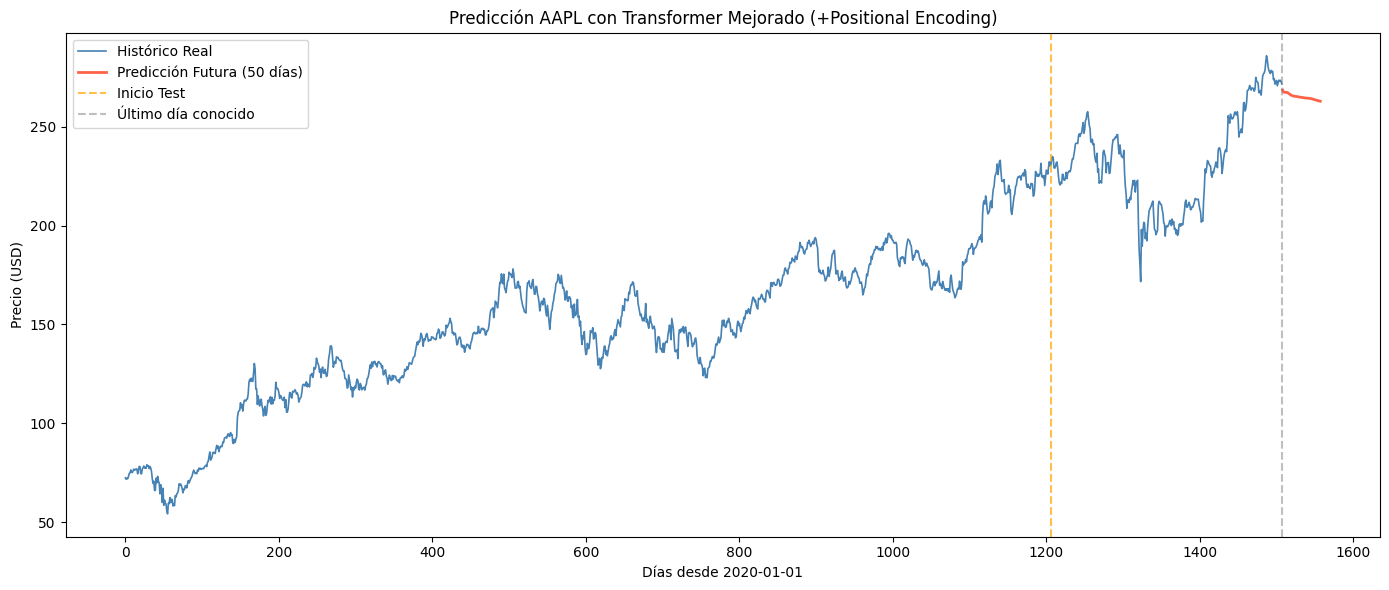

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(range(len(data)),
         scaler.inverse_transform(data_scaled_full),
         label='Histórico Real', color='steelblue', linewidth=1.2)
plt.plot(range(len(data), len(data) + 50),
         future_predictions,
         label='Predicción Futura (50 días)', color='tomato', linewidth=2)
plt.axvline(x=split_idx, color='orange', linestyle='--', alpha=0.7, label='Inicio Test')
plt.axvline(x=len(data) - 1, color='gray', linestyle='--', alpha=0.5, label='Último día conocido')
plt.title('Predicción AAPL con Transformer Mejorado (+Positional Encoding)')
plt.xlabel('Días desde 2020-01-01')
plt.ylabel('Precio (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 2.5 Métricas de Evaluación — Conjunto de Test

#### ¿Por qué las métricas están en dólares (USD)?

El modelo **nunca ve ni predice precios en dólares directamente**. Trabaja siempre en espacio normalizado `[0, 1]`. El paso a USD ocurre al final mediante la transformación inversa del `MinMaxScaler`.

**Transformación directa** (preprocesado — antes de entrenar):

$$x_{scaled} = \frac{x_{USD} - x_{min}}{x_{max} - x_{min}}$$

donde `x_min` y `x_max` son el precio mínimo y máximo **del conjunto de entrenamiento** (≈ $53 y ≈ $199 en este caso).

**Transformación inversa** (postprocesado — después de predecir):

$$x_{USD} = x_{scaled} \cdot (x_{max} - x_{min}) + x_{min}$$

Esto es lo que hace `scaler.inverse_transform(...)` en el código: convierte la predicción normalizada `ŷ ∈ [0, 1]` de vuelta a dólares reales.

**Ejemplo concreto:**

| Paso | Valor |
|---|---|
| Precio real | $230.00 USD |
| Normalizado | $(230 - 53) / (199 - 53) = 0.787$ |
| Predicción del modelo | $0.772$ |
| Desnormalizado | $0.772 × (199 - 53) + 53 = 225.8$ USD |
| Error absoluto (MAE) | $|230 - 225.8| = 4.2$ **USD** |

Por eso el **MAE aparece en dólares** — es el error medio después de deshacer la normalización. Lo mismo aplica al RMSE. El MAPE y R² son adimensionales (trabajan con cocientes o varianzas relativas) y no dependen de la escala.

---

Se evalúa la predicción **un paso adelante** sobre el 20 % de datos reservados (los más recientes, ~300 días). Adicionalmente se calcula la **Directional Accuracy**: porcentaje de días en que el modelo acierta si el precio sube o baja — relevante para aplicaciones de trading.

| Métrica | Descripción |
|---|---|
| RMSE (USD) | Error típico en dólares — raíz del error cuadrático medio |
| MAE (USD) | Error medio absoluto en dólares — robusto a outliers |
| MAPE (%) | Error relativo medio — independiente de la escala del precio |
| R² | Fracción de varianza del precio explicada por el modelo |
| Directional Accuracy (%) | Acierto en la dirección del movimiento diario |

Rango del scaler (solo train): min=$54.21  max=$233.02
Fórmula directa  : x_scaled = (x_USD - 54.21) / (233.02 - 54.21)
Fórmula inversa  : x_USD    = x_scaled × 178.80 + 54.21

  Métricas AAPL — Conjunto de Test (20 %)
  RMSE              : $8.75  ← error típico en USD
  MAE               : $6.80  ← error medio absoluto en USD
  MAPE              : 3.01 %  ← error relativo (sin escala)
  R²                : 0.8738   ← varianza explicada (1 = perfecto)
  Directional Acc.  : 53.82 %  ← acierto en dirección del movimiento

  Referencia: un clasificador aleatorio tendría ~50 % de Directional Acc.


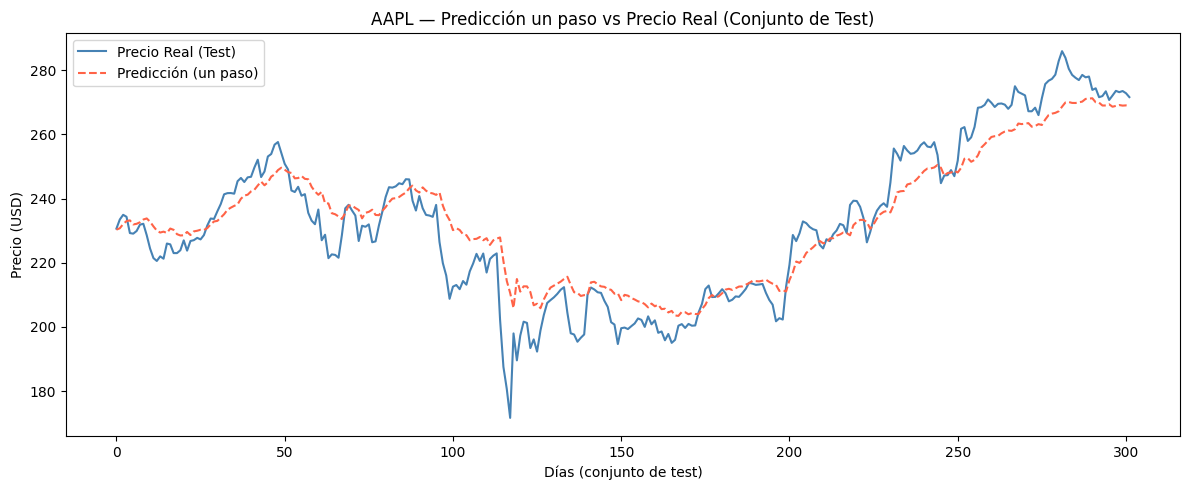

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Parámetros del scaler (ajustado solo con train) ───────────────────────────
x_min = scaler.data_min_[0]
x_max = scaler.data_max_[0]
print(f"Rango del scaler (solo train): min=${x_min:.2f}  max=${x_max:.2f}")
print(f"Fórmula directa  : x_scaled = (x_USD - {x_min:.2f}) / ({x_max:.2f} - {x_min:.2f})")
print(f"Fórmula inversa  : x_USD    = x_scaled × {x_max - x_min:.2f} + {x_min:.2f}")
print()

# ── Predicciones sobre el conjunto de test ────────────────────────────────────
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test).cpu().numpy()
y_test_np_orig = y_test.cpu().numpy()

# Desnormalizar — aquí es donde los números pasan de [0,1] a USD
test_preds_usd = scaler.inverse_transform(test_preds_scaled)
y_test_usd     = scaler.inverse_transform(y_test_np_orig)

# ── Métricas en espacio original (USD) ────────────────────────────────────────
mse  = mean_squared_error(y_test_usd, test_preds_usd)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_usd, test_preds_usd)
mape = np.mean(np.abs((y_test_usd - test_preds_usd) / (np.abs(y_test_usd) + 1e-8))) * 100
r2   = r2_score(y_test_usd, test_preds_usd)

# ── Directional Accuracy ──────────────────────────────────────────────────────
dir_real = np.sign(np.diff(y_test_usd.flatten()))
dir_pred = np.sign(np.diff(test_preds_usd.flatten()))
dir_acc  = np.mean(dir_real == dir_pred) * 100

print("=" * 50)
print("  Métricas AAPL — Conjunto de Test (20 %)")
print("=" * 50)
print(f"  RMSE              : ${rmse:.2f}  ← error típico en USD")
print(f"  MAE               : ${mae:.2f}  ← error medio absoluto en USD")
print(f"  MAPE              : {mape:.2f} %  ← error relativo (sin escala)")
print(f"  R²                : {r2:.4f}   ← varianza explicada (1 = perfecto)")
print(f"  Directional Acc.  : {dir_acc:.2f} %  ← acierto en dirección del movimiento")
print()
print("  Referencia: un clasificador aleatorio tendría ~50 % de Directional Acc.")

# ── Visualización: predicciones vs valores reales en el test set ──────────────
plt.figure(figsize=(12, 5))
plt.plot(y_test_usd,     label='Precio Real (Test)',   color='steelblue')
plt.plot(test_preds_usd, label='Predicción (un paso)', color='tomato', linestyle='--')
plt.title('AAPL — Predicción un paso vs Precio Real (Conjunto de Test)')
plt.xlabel('Días (conjunto de test)')
plt.ylabel('Precio (USD)')
plt.legend()
plt.tight_layout()
plt.show()